In [3]:
#!pip install xarray
#!pip install scipy
#!pip install cdsapi

#### Import Libraries

In [4]:
import xarray as xr
import numpy as np
import pandas as pd
import marineHeatWaves as mhw
import datetime as dt
import math

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata
from matplotlib.gridspec import GridSpec

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

#### Define Slice Function

The coordinates have to be defined in 0-360 format.

In [5]:
def spatial_subset(ds):
    out = ds.sel(lon = slice(350.0, 355.0),
                 lat = slice(36.0, 42.3))
    return out

## Get Baseline

The baselilne used is 1991-2021

In [6]:
baseline_df = pd.DataFrame()
for year in range(1981, 2022):

    var = xr.open_dataset(f"oisst_daily/sst.day.mean.{year}.nc", 
                        engine="netcdf4", decode_times=True)
    
    print(f'Opening {year}')
    
    var_sel = spatial_subset(var)
    
    var_sst = var_sel["sst"]

    baseline_df = pd.concat([baseline_df, var_sst.to_dataframe()])
    
del var

Opening 1981
Opening 1982
Opening 1983
Opening 1984
Opening 1985
Opening 1986
Opening 1987
Opening 1988
Opening 1989
Opening 1990
Opening 1991
Opening 1992
Opening 1993
Opening 1994
Opening 1995
Opening 1996
Opening 1997
Opening 1998
Opening 1999
Opening 2000
Opening 2001
Opening 2002
Opening 2003
Opening 2004
Opening 2005
Opening 2006
Opening 2007
Opening 2008
Opening 2009
Opening 2010
Opening 2011
Opening 2012
Opening 2013
Opening 2014
Opening 2015
Opening 2016
Opening 2017
Opening 2018
Opening 2019
Opening 2020
Opening 2021


## Years to be Analysed

In [7]:
y2023 = xr.open_dataset("oisst_daily/sst.day.mean.2023.nc", 
                        engine="netcdf4", decode_times=True)

#### Slice datasets' coordinates

In [8]:
y2023_sel = spatial_subset(y2023)
y2023_sst = y2023_sel["sst"]
y2023_time = y2023_sel["time"]

In [9]:
baseline_df = baseline_df.reset_index()

y2023_df = y2023_sst.to_dataframe().reset_index()


## Conversion to ordinal time

In [10]:
def to_ordinal(time_array):
    ordinals = []

    for t in time_array:
        # Case 1: numpy.datetime64
        if isinstance(t, np.datetime64):
            ts = pd.Timestamp(t)
            ordinals.append(ts.to_pydatetime().date().toordinal())

        # Case 2: cftime objects
        else:
            ordinals.append(dt.date(t.year, t.month, t.day).toordinal())

    return np.array(ordinals)

## Detect MHWs

In [11]:
y2023_time_ord = to_ordinal(y2023_df['time'])
baseline_time_ord = to_ordinal(baseline_df["time"])

In [12]:
results = []

for (lat, lon), group in y2023_df.groupby(["lat", "lon"]):

    # Subset baseline dataframe for this grid point
    baseline_point = (
    baseline_df
    .query("lat == @lat and lon == @lon")
    .sort_values("time")
)

    # Subset baseline time ordinals USING THE SAME ROWS
    baseline_idx = baseline_point.index.values
    baseline_time_ord_sub = baseline_time_ord[baseline_idx]
    baseline_temp = baseline_point["sst"].values


    t_ord = to_ordinal(group["time"])
    temp = group["sst"].values

    mhw_events, clim = mhw.detect(
    t_ord,
    temp,
    climatologyPeriod=[1981, 2010],
    alternateClimatology=[baseline_time_ord_sub, baseline_temp]
)


    mhw_df = pd.DataFrame(mhw_events)
    mhw_df["lat"] = lat
    mhw_df["lon"] = lon

    results.append(mhw_df)

mhw_all = pd.concat(results, ignore_index=True)
mhw_all.to_csv("mhw_events_2023.csv", index=False)

/var/folders/wq/98_by44j0113pwx7jtjgd74w0000gn/T/ipykernel_64131/1546679377.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  mhw_all = pd.concat(results, ignore_index=True)


## MHWs Analysis

In [13]:
mhw_all = pd.read_csv("mhw_events_2023.csv")

In [14]:
mhw_all["date_start"] = pd.to_datetime(mhw_all["date_start"], errors="coerce")
mhw_all["date_end"] = pd.to_datetime(mhw_all["date_end"], errors="coerce")

In [15]:
mhw_all['duration'] = mhw_all['date_end'] - mhw_all['date_start']
mhw_all['duration'].head()

0    41 days
1   129 days
2     4 days
3   103 days
4   179 days
Name: duration, dtype: timedelta64[ns]

In [16]:
mhw_all = mhw_all.set_index(["lat", "lon"]).sort_index()
grouped = mhw_all.groupby(level=["lat", "lon"])


In [17]:
mhw_all.columns

Index(['time_start', 'time_end', 'time_peak', 'date_start', 'date_end',
       'date_peak', 'index_start', 'index_end', 'index_peak', 'duration',
       'duration_moderate', 'duration_strong', 'duration_severe',
       'duration_extreme', 'intensity_max', 'intensity_mean', 'intensity_var',
       'intensity_cumulative', 'intensity_max_relThresh',
       'intensity_mean_relThresh', 'intensity_var_relThresh',
       'intensity_cumulative_relThresh', 'intensity_max_abs',
       'intensity_mean_abs', 'intensity_var_abs', 'intensity_cumulative_abs',
       'category', 'rate_onset', 'rate_decline', 'n_events'],
      dtype='object')

In [18]:
for (lat, lon), df in grouped:
    print(lat, lon)
    print(df[['date_start', 'date_end','duration', 'category']])
    print()


36.125 350.125
               date_start   date_end duration  category
lat    lon                                             
36.125 350.125 2023-01-01 2023-02-11  41 days    Strong
       350.125 2023-02-21 2023-06-30 129 days    Strong
       350.125 2023-07-12 2023-07-16   4 days  Moderate
       350.125 2023-09-19 2023-12-31 103 days    Severe

36.125 350.375
               date_start   date_end duration category
lat    lon                                            
36.125 350.375 2023-01-01 2023-06-29 179 days   Severe
       350.375 2023-09-19 2023-12-31 103 days   Severe

36.125 350.625
               date_start   date_end duration  category
lat    lon                                             
36.125 350.625 2023-01-01 2023-06-30 180 days    Severe
       350.625 2023-07-08 2023-07-16   8 days  Moderate
       350.625 2023-09-18 2023-12-31 104 days    Strong

36.125 350.875
               date_start   date_end duration  category
lat    lon                                   

In [19]:
mhw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   time_start                      0 non-null      float64
 1   time_end                        0 non-null      float64
 2   time_peak                       0 non-null      float64
 3   date_start                      0 non-null      float64
 4   date_end                        0 non-null      float64
 5   date_peak                       0 non-null      float64
 6   index_start                     0 non-null      float64
 7   index_end                       0 non-null      float64
 8   index_peak                      0 non-null      float64
 9   duration                        0 non-null      float64
 10  duration_moderate               0 non-null      float64
 11  duration_strong                 0 non-null      float64
 12  duration_severe                 0 non-null      

## Graphs

In [24]:
# =================================================
# PREP: MHW catalogue (2023 only)
# =================================================

mhw_df = mhw_all.reset_index()

mhw_df["date_start"] = pd.to_datetime(mhw_df["date_start"])
mhw_df["date_end"] = pd.to_datetime(mhw_df["date_end"])

# =================================================
# SPLIT EVENTS INTO MONTHLY DURATIONS
# =================================================

rows = []

for _, row in mhw_df.iterrows():
    start = row["date_start"]
    end = row["date_end"]
    current = start

    while current <= end:
        month_start = current.replace(day=1)
        next_month = month_start + pd.offsets.MonthBegin(1)
        month_end = min(end, next_month - pd.Timedelta(days=1))

        duration_days = (month_end - current).days + 1

        rows.append({
            "lat": row["lat"],
            "lon": row["lon"],
            "month": current.month,
            "duration_days": duration_days
        })

        current = month_end + pd.Timedelta(days=1)

monthly_events = pd.DataFrame(rows)

# =================================================
# AGGREGATE: SUM DURATION PER GRID PER MONTH
# =================================================

monthly_dfs = {}

for month in range(1, 13):
    df_m = monthly_events[monthly_events["month"] == month]

    stats_m = (
        df_m
        .groupby(["lat", "lon"])
        .agg(sum_duration_days=("duration_days", "sum"))
        .reset_index()
    )

    monthly_dfs[month] = stats_m

In [25]:
monthly_dfs

{1:         lat      lon  sum_duration_days
 0    36.125  350.125                 31
 1    36.125  350.375                 31
 2    36.125  350.625                 31
 3    36.125  350.875                 31
 4    36.125  351.125                 31
 ..      ...      ...                ...
 161  41.875  351.125                 18
 162  42.125  350.125                 31
 163  42.125  350.375                 31
 164  42.125  350.625                 27
 165  42.125  350.875                 24
 
 [166 rows x 3 columns],
 2:         lat      lon  sum_duration_days
 0    36.125  350.125                 19
 1    36.125  350.375                 28
 2    36.125  350.625                 28
 3    36.125  350.875                 28
 4    36.125  351.125                 28
 ..      ...      ...                ...
 97   41.875  350.375                 19
 98   41.875  350.625                  9
 99   42.125  350.125                 19
 100  42.125  350.375                 18
 101  42.125  350.625   

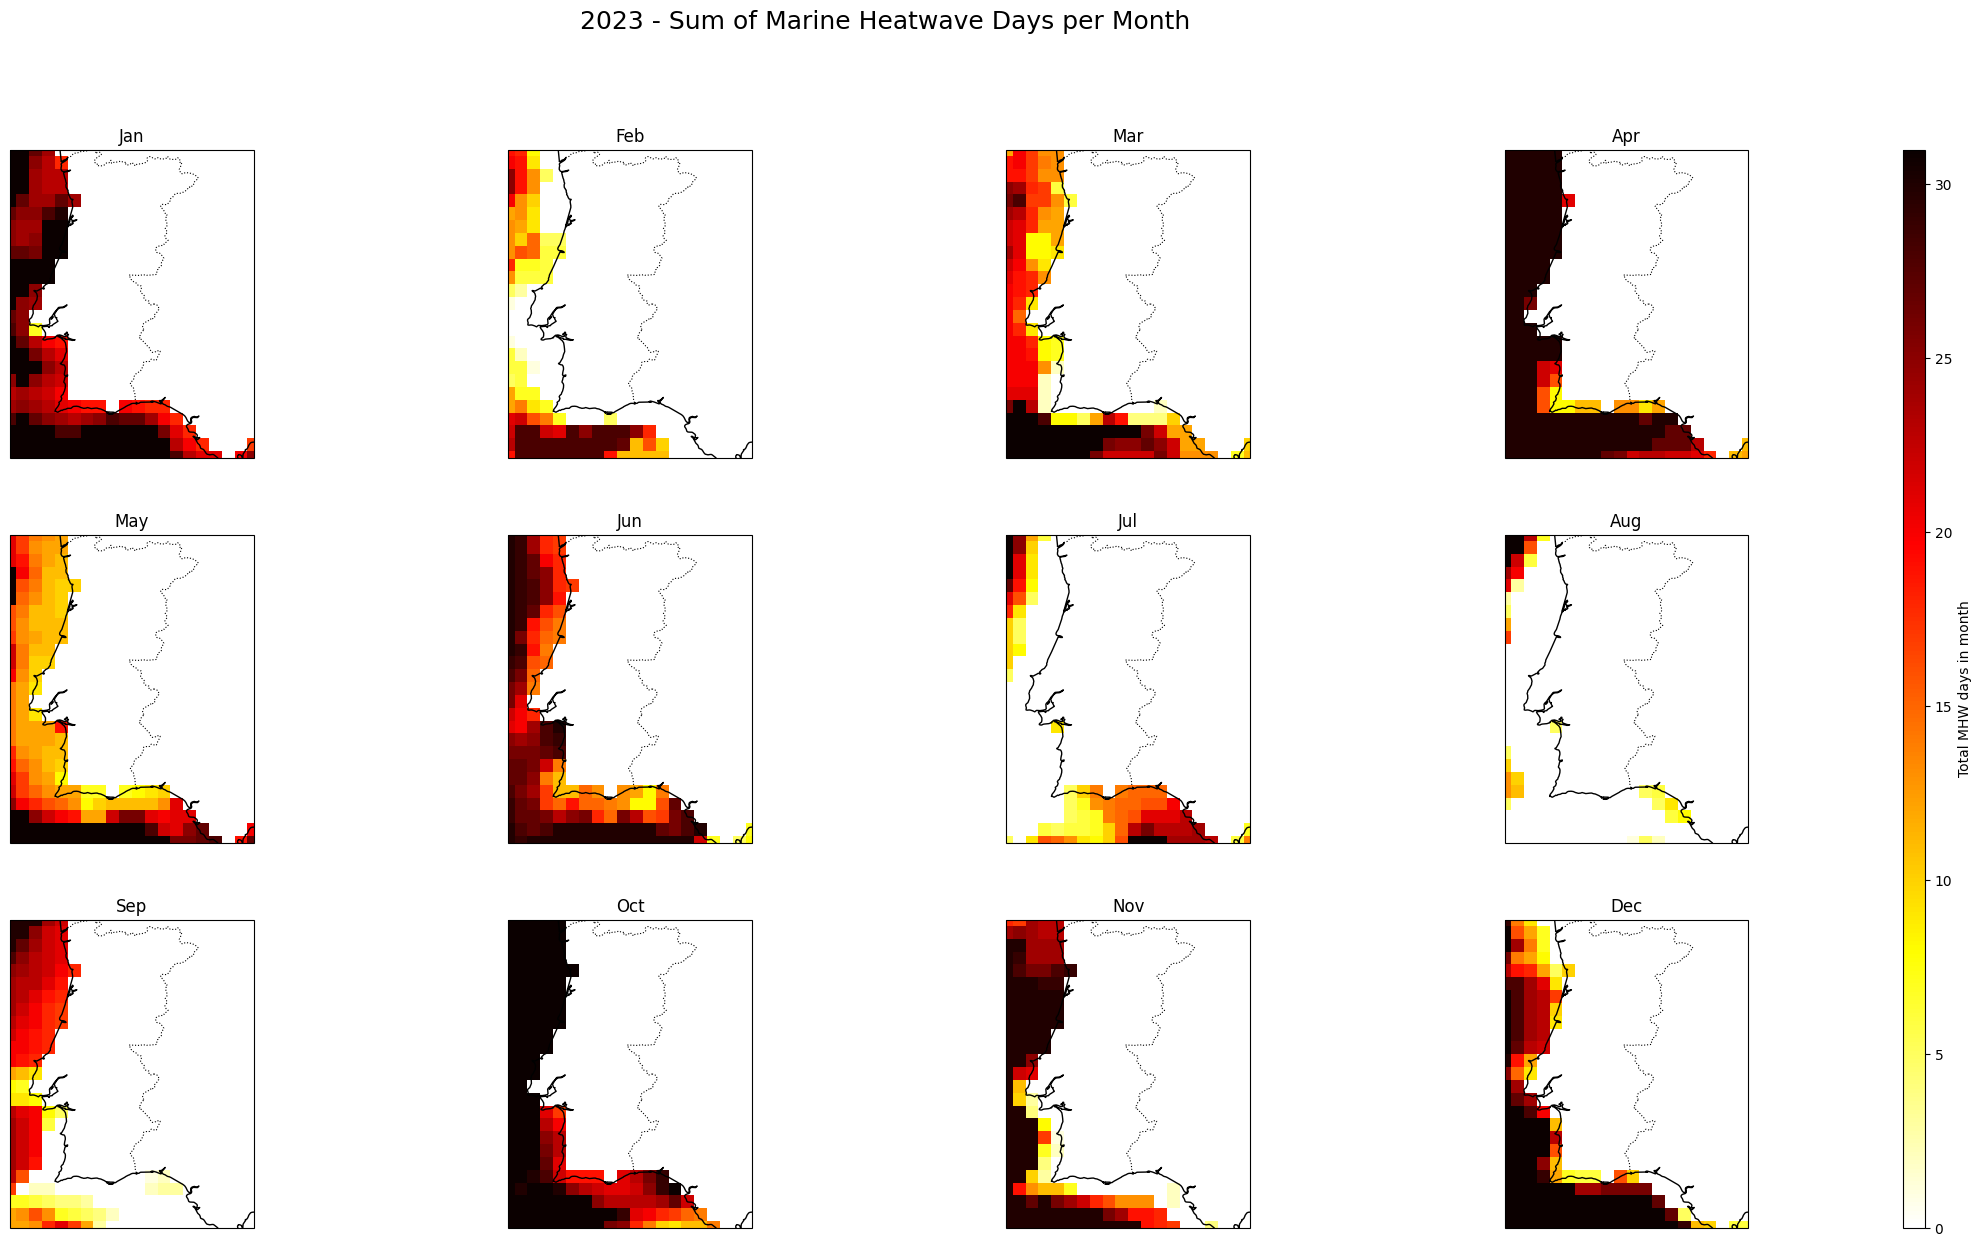

In [27]:
# =================================================
# CELL-BASED MONTHLY MAPS (NO INTERPOLATION)
# =================================================

# Base grid
lons = y2023_sel["lon"].values
lats = y2023_sel["lat"].values
lon2d, lat2d = np.meshgrid(lons, lats)

# Ocean mask
ocean_mask = ~np.isnan(y2023_sel["sst"].isel(time=0).values)

# Figure
fig = plt.figure(figsize=(26, 14))
gs = GridSpec(3, 5, width_ratios=[1, 1, 1, 1, 0.05], wspace=0.15, hspace=0.25)

axes = [fig.add_subplot(gs[i // 4, i % 4], projection=ccrs.PlateCarree()) for i in range(12)]
cax = fig.add_subplot(gs[:, -1])

# Color scale
vmin = 0
vmax = max(df["sum_duration_days"].max() for df in monthly_dfs.values() if not df.empty)

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# =================================================
# PLOT EACH MONTH
# =================================================

for ax, month in zip(axes, range(1, 13)):

    # Start with zero everywhere
    grid = np.zeros((len(lats), len(lons)))

    # Fill values for cells with MHWs
    df = monthly_dfs[month]
    for _, row in df.iterrows():
        i = np.where(lats == row["lat"])[0][0]
        j = np.where(lons == row["lon"])[0][0]
        grid[i, j] = row["sum_duration_days"]

    # Mask land only
    grid = np.ma.masked_where(~ocean_mask, grid)

    ax.set_extent(
        [lons.min(), lons.max(), lats.min(), lats.max()],
        crs=ccrs.PlateCarree()
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.8)

    mesh = ax.pcolormesh(
        lon2d, lat2d, grid,
        cmap="hot_r",
        shading="nearest",   # key line
        vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree()
    )

    ax.set_title(month_names[month - 1])

# Colorbar + title
cbar = fig.colorbar(mesh, cax=cax)
cbar.set_label("Total MHW days in month")

fig.suptitle("2023 - Sum of Marine Heatwave Days per Month", fontsize=18, y=0.98)

plt.show()
